In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, widgets
sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("netflix_titles.csv") 
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()   # Check data types and missing values
df.describe()  # Summary statistics
df.isnull().sum()  # Count missing values per column


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Fill missing country values with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# Fill missing director values with 'Unknown'
df['director'] = df['director'].fillna('Unknown')

# Optional: Fill missing rating with 'Not Rated'
df['rating'] = df['rating'].fillna('Not Rated')

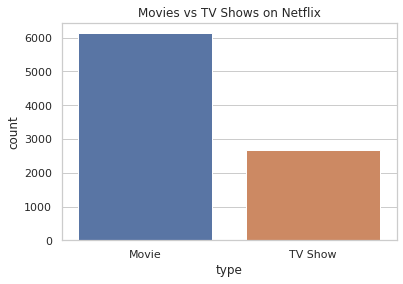

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

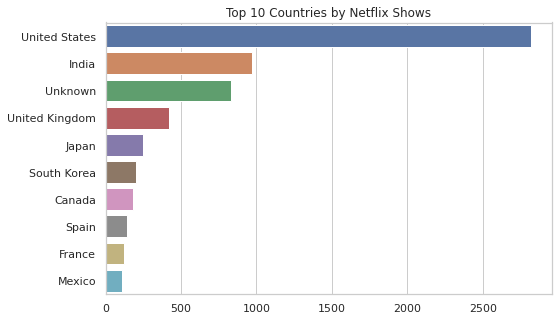

In [6]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Netflix Shows")
plt.show()

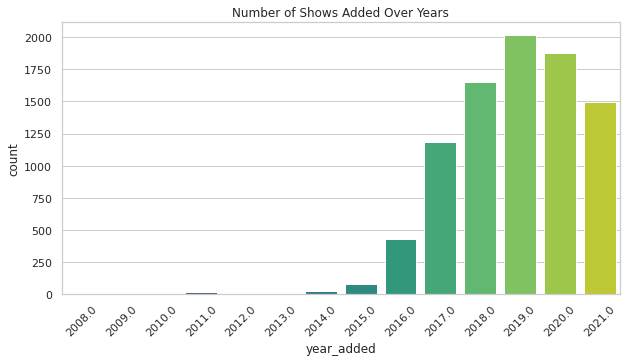

In [7]:
df['year_added'] = df['date_added'].dt.year
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='year_added', palette="viridis")
plt.title("Number of Shows Added Over Years")
plt.xticks(rotation=45)
plt.show()

In [8]:
def plot_genres(content_type):
    filtered = df[df['type'] == content_type]
    
    # Split genres (some have multiple genres separated by ',')
    genres = filtered['listed_in'].str.split(',', expand=True).stack()
    genre_counts = genres.value_counts().head(10)
    
    plt.figure(figsize=(8,5))
    sns.barplot(x=genre_counts.values, y=genre_counts.index)
    plt.title(f"Top 10 Genres for {content_type}s")
    plt.xlabel("Count")
    plt.show()

# Dropdown widget
interact(plot_genres, content_type=widgets.Dropdown(
    options=df['type'].unique(),
    description='Content Type:'
))

interactive(children=(Dropdown(description='Content Type:', options=('Movie', 'TV Show'), value='Movie'), Outp…

<function __main__.plot_genres(content_type)>